In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_excel('QE CONNECTION DATASET.xlsx', sheet_name='300mm')
df = df.rename(columns={'ShearForce(N)': 'ShearForce'})
df.head()

,ID,AppliedLoad(N),ShearForce,RebarDiameter,InternodeInfill,BambooMeanDiameter,BambooMeanThickness
0,S25,6314,4735.5,10,1 internode,107.735,9.0400
1,S26,7822,5866.5,10,1 internode,111.805,7.6500
2,S27,5746,4309.5,10,1 internode,104.815,7.9575
3,S28,6350,4762.5,10,1 internode,108.615,9.6650
4,S29,9700,7275.0,10,1 internode,104.625,8.3000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36 non-null     object 
 1   AppliedLoad(N)       36 non-null     int64  
 2   ShearForce           36 non-null     float64
 3   RebarDiameter        36 non-null     int64  
 4   InternodeInfill      36 non-null     object 
 5   BambooMeanDiameter   36 non-null     float64
 6   BambooMeanThickness  36 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 2.1+ KB


In [4]:
df['InternodeInfill'] = df['InternodeInfill'].apply(lambda x: x[0])
df['InternodeInfill'] = pd.to_numeric(df['InternodeInfill'], errors='coerce')

In [5]:
df.head()

,ID,AppliedLoad(N),ShearForce,RebarDiameter,InternodeInfill,BambooMeanDiameter,BambooMeanThickness
0,S25,6314,4735.5,10,1,107.735,9.0400
1,S26,7822,5866.5,10,1,111.805,7.6500
2,S27,5746,4309.5,10,1,104.815,7.9575
3,S28,6350,4762.5,10,1,108.615,9.6650
4,S29,9700,7275.0,10,1,104.625,8.3000


In [6]:
#1. anong combination ng rebar at number of internodes ang nagbibigay ng high shear capacity
#2. and nakakaapekto rin ba yung diameter and thickness ng bamboo sa result

<Axes: xlabel='BambooMeanDiameter', ylabel='ShearForce'>

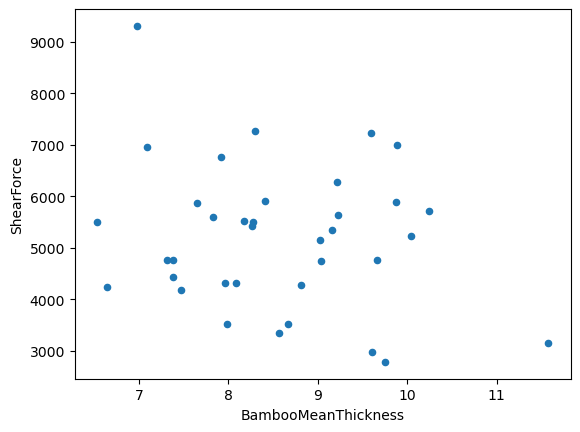

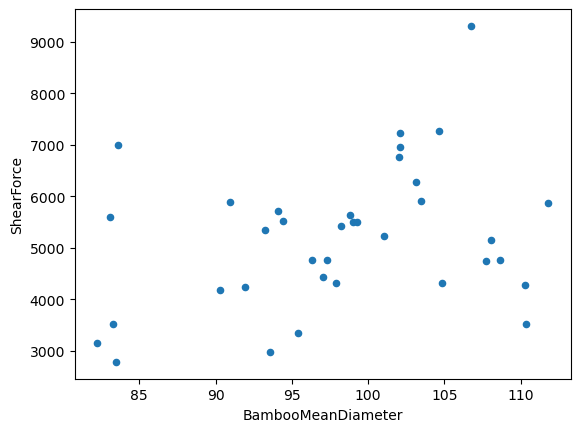

In [7]:
df[['BambooMeanThickness', 'ShearForce']].plot(kind='scatter', x='BambooMeanThickness', y='ShearForce')
df[['BambooMeanDiameter', 'ShearForce']].plot(kind='scatter', x='BambooMeanDiameter', y='ShearForce')

In [8]:
df[['BambooMeanDiameter', 'BambooMeanThickness', 'ShearForce']].corr('pearson')

,BambooMeanDiameter,BambooMeanThickness,ShearForce
BambooMeanDiameter,1.000000,-0.20661,0.308898
BambooMeanThickness,-0.206610,1.00000,-0.195500
ShearForce,0.308898,-0.19550,1.000000


In [9]:
df2 = pd.read_excel('QE CONNECTION DATASET.xlsx', sheet_name='450mm')
df2 = df2.rename(columns={'ShearForce(N)': 'ShearForce'})
df2.head()

,ID,AppliedLoad(N),ShearForce,RebarDiameter,InternodeInfill,BambooMeanDiameter,BambooMeanThickness
0,S25-2,5146,3216.25,10,1 internode,82.25,6.675
1,S26-2,6556,4097.50,10,1 internode,93.20,6.725
2,S27-2,5694,3558.75,10,1 internode,95.85,8.425
3,S28-2,6834,4271.25,10,1 internode,92.55,8.550
4,S29-2,8072,5045.00,10,1 internode,91.20,8.250


In [10]:
df2['InternodeInfill'] = df2['InternodeInfill'].apply(lambda x: x[0])
df2['InternodeInfill'] = pd.to_numeric(df2['InternodeInfill'], errors='coerce')

In [11]:
df2.groupby('RebarDiameter')[['BambooMeanDiameter', 'BambooMeanThickness', 'ShearForce']].corr('pearson')

BambooMeanDiameter  BambooMeanThickness  \
RebarDiameter                                                                
10            BambooMeanDiameter             1.000000             0.207661   
              BambooMeanThickness            0.207661             1.000000   
              ShearForce                     0.203110             0.243437   
12            BambooMeanDiameter             1.000000             0.462098   
              BambooMeanThickness            0.462098             1.000000   
              ShearForce                     0.645699             0.693429   
16            BambooMeanDiameter             1.000000             0.253337   
              BambooMeanThickness            0.253337             1.000000   
              ShearForce                     0.515506             0.625383   

                                   ShearForce  
RebarDiameter                                  
10            BambooMeanDiameter     0.203110  
              BambooMeanThickness    0.243437  
              ShearForce             1.000000  
12            BambooMeanDiameter     0.645699  
              BambooMeanThickness    0.693429  
              ShearForce             1.000000  
16            BambooMeanDiameter     0.515506  
              BambooMeanThickness    0.625383  
              ShearForce             1.000000

In [12]:
df2[['BambooMeanDiameter', 'BambooMeanThickness', 'ShearForce']].corr('pearson')

,BambooMeanDiameter,BambooMeanThickness,ShearForce
BambooMeanDiameter,1.000000,0.308022,0.485930
BambooMeanThickness,0.308022,1.000000,0.554614
ShearForce,0.485930,0.554614,1.000000


<Axes: xlabel='BambooMeanDiameter', ylabel='ShearForce'>

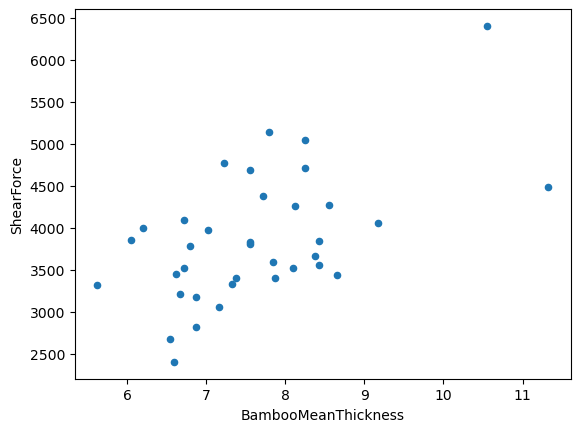

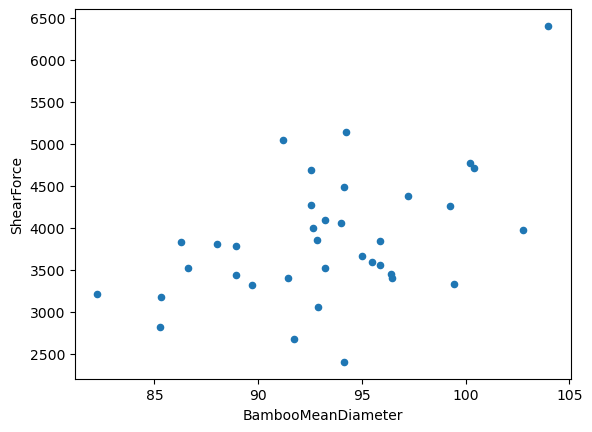

In [13]:
df2[['BambooMeanThickness', 'ShearForce']].plot(kind='scatter', x='BambooMeanThickness', y='ShearForce')
df2[['BambooMeanDiameter', 'ShearForce']].plot(kind='scatter', x='BambooMeanDiameter', y='ShearForce')

#THERE IS SEEM TO HAVE LINEAR RELATIONSHIP BETWEEN THE INDPENDENT VARIABLES AND TARGET VARIABLES. (CHECK)

In [14]:
#create a linear regression to check if these are factors for the target variable.
#TAKE NOTE, FOR 300mm pa lang itong analysis. To follow yung for 450mm. :)

import statsmodels.api as sm

In [15]:
X = df.drop(columns=['ID', 'ShearForce', 'AppliedLoad(N)'])
y = df['ShearForce']

X = sm.add_constant(X)

model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             ShearForce   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     2.225
Date:                Sun, 27 Jul 2025   Prob (F-statistic):             0.0892
Time:                        07:58:15   Log-Likelihood:                -306.47
No. Observations:                  36   AIC:                             622.9
Df Residuals:                      31   BIC:                             630.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1035.8442   4

In [16]:
#test for homoscedasticity
from statsmodels.stats.diagnostic import het_breuschpagan
residuals = model.resid
exog_het = X

lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(residuals, X)
f_pvalue
#fail to reject null hypothesis, meaning homoscedasticity does not exist = errors are constant across all independent variables (CHECK)

0.9067179928539976

In [17]:
#jarque-bera test for normality of residuals
import scipy.stats as stats
jb_stat, p_value = stats.jarque_bera(residuals)

p_value
#fail to reject null hypothesis, meaning the distribution of residuals is normal (CHECK)

0.14768300217372002

In [18]:
#test for multicolinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
#X = sm.add_constant(X) we already added constant from building the model

vif_test = pd.DataFrame()
vif_test['feature'] = X.columns
vif_test['VIF_value'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_test.sort_values(by='VIF_value'))

#variables are not correlated to each other (CHECK)

               feature   VIF_value
1        RebarDiameter    1.019777
4  BambooMeanThickness    1.087532
2      InternodeInfill    1.305292
3   BambooMeanDiameter    1.374011
0                const  393.930864


In [19]:
#450mm starts here
X2 = df2.drop(columns=['ID', 'ShearForce', 'AppliedLoad(N)'])
y2 = df2['ShearForce']

X2 = sm.add_constant(X2)

model = sm.OLS(y2,X2).fit()
print(model.summary())

# Linearity: as per plot observation (CHECK)
# Independence of Errors: DurbinWatsonTest: Fail to reject H_0 ==> residuals are not correlated ==> normally distributed (CHECK)

                            OLS Regression Results                            
Dep. Variable:             ShearForce   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     7.355
Date:                Sun, 27 Jul 2025   Prob (F-statistic):           0.000275
Time:                        07:58:15   Log-Likelihood:                -277.86
No. Observations:                  36   AIC:                             565.7
Df Residuals:                      31   BIC:                             573.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -2452.6646   1

In [20]:
#test for homoscedasticity
residuals = model.resid
exog_het = X2

lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(residuals, X2)
f_pvalue

# Fail to reject H_0 ==> Variance of error is homoscedastic (constant over independent variables) (CHECK)

0.5672549195272087

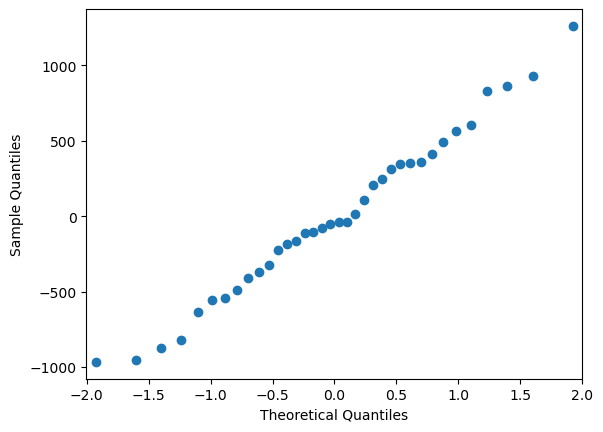

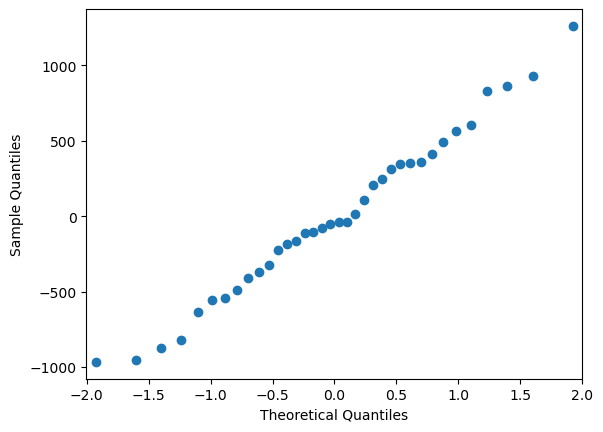

In [21]:
sm.qqplot(model.resid)

In [22]:
#test for multicolinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
#X2 = sm.add_constant(X2) we already added constant from building the model

vif_test = pd.DataFrame()
vif_test['feature'] = X2.columns
vif_test['VIF_value'] = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]

print(vif_test.sort_values(by='VIF_value'))

#variables are not correlated to each other (CHECK)

               feature   VIF_value
1        RebarDiameter    1.000346
2      InternodeInfill    1.015265
4  BambooMeanThickness    1.112045
3   BambooMeanDiameter    1.119343
0                const  392.982493


In [23]:
#300mm and 450mm starts here
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

df3 = pd.concat([df, df2])
df3['Load'] = df3['ID'].apply(lambda x: 450 if "-" in x else 300)

In [24]:
df3 = df3.rename(columns={'ShearForce(N)': 'ShearForce'})
df3.head()

,ID,AppliedLoad(N),ShearForce,RebarDiameter,InternodeInfill,BambooMeanDiameter,BambooMeanThickness,Load
0,S25,6314,4735.5,10,1,107.735,9.0400,300
1,S26,7822,5866.5,10,1,111.805,7.6500,300
2,S27,5746,4309.5,10,1,104.815,7.9575,300
3,S28,6350,4762.5,10,1,108.615,9.6650,300
4,S29,9700,7275.0,10,1,104.625,8.3000,300


In [25]:
X3 = df3.drop(columns=['ID', 'ShearForce', 'AppliedLoad(N)'])
y3 = df3['ShearForce']

In [26]:
model = smf.ols('ShearForce ~ Load + RebarDiameter + BambooMeanDiameter + BambooMeanThickness + InternodeInfill', data=df3).fit()

print(model.summary())
#check if the assumptions for linear regression are met.

                            OLS Regression Results                            
Dep. Variable:             ShearForce   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     8.001
Date:                Sun, 27 Jul 2025   Prob (F-statistic):           6.08e-06
Time:                        07:58:15   Log-Likelihood:                -600.92
No. Observations:                  72   AIC:                             1214.
Df Residuals:                      66   BIC:                             1228.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             700.3239   2

<Axes: xlabel='BambooMeanThickness', ylabel='ShearForce'>

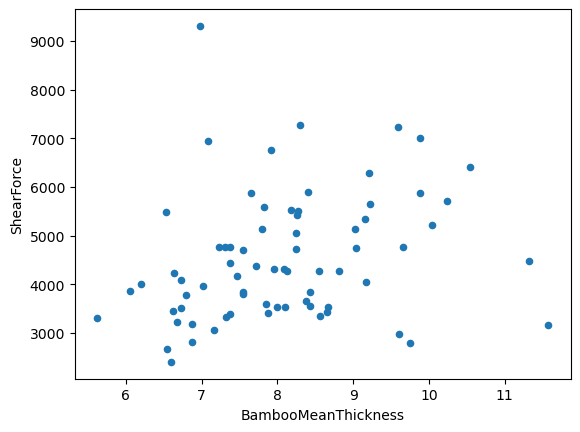

In [27]:
df3.plot(x='BambooMeanThickness', y='ShearForce', kind='scatter')

In [28]:
ancova_table = anova_lm(model)

In [29]:
print(ancova_table)

#Load does affect the result of ShearForce

                       df        sum_sq       mean_sq          F    PR(>F)
Load                  1.0  3.219162e+07  3.219162e+07  28.382074  0.000001
RebarDiameter         1.0  2.037242e+06  2.037242e+06   1.796155  0.184774
BambooMeanDiameter    1.0  1.035712e+07  1.035712e+07   9.131458  0.003574
BambooMeanThickness   1.0  5.591226e+05  5.591226e+05   0.492956  0.485080
InternodeInfill       1.0  2.276995e+05  2.276995e+05   0.200754  0.655581
Residual             66.0  7.485876e+07  1.134224e+06        NaN       NaN


In [30]:
lm_statistic, lm_p_value, f_statistic, f_p_value = het_breuschpagan(model.resid, model.model.exog)


# Print the results
print(f"Lagrange Multiplier Statistic: {lm_statistic}")
print(f"P-value: {lm_p_value}")
print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")

#fail to reject null hypothesis

Lagrange Multiplier Statistic: 8.571037324954418
P-value: 0.1274466512878009
F-statistic: 1.7836913598763513
F p-value: 0.12833898636800328


<Axes: xlabel='ShearForce', ylabel='Load'>

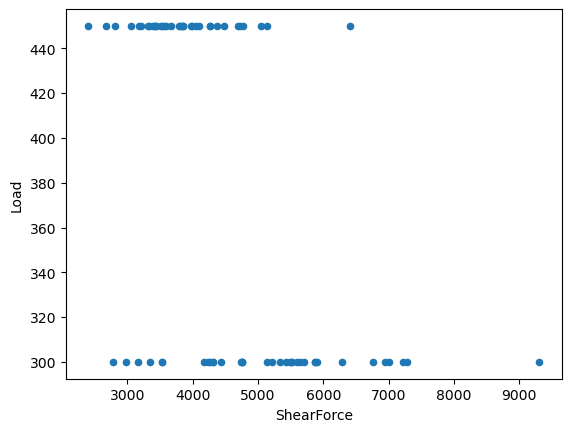

In [31]:
df3[['Load', 'ShearForce']].plot(y='Load', x='ShearForce', kind='scatter')